# 스케줄링 GA 실행 결과

## 모듈 import

In [1]:
import os
import json
import time
import random
import simpy
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler
from algorithms.genetic.encoder import encode
from algorithms.genetic.decoder import decode
from algorithms.genetic.ga import GA

## 환경 설정

In [2]:
load_dotenv(override=True)


BASE_DATA_PATH = os.environ['BASE_DATA_PATH']

PM_LEVELS      = json.loads(os.environ['PM_LEVELS'])
POP_SIZE       = int(os.environ['POP_SIZE'])
N_GENERATIONS  = int(os.environ['N_GENERATIONS'])
CROSSOVER_RATE = float(os.environ['CROSSOVER_RATE'])
MUT_JOB        = float(os.environ['MUT_JOB'])
MUT_MACHINE    = float(os.environ['MUT_MACHINE'])
MUT_PM         = float(os.environ['MUT_PM'])
TOURNAMENT_K   = int(os.environ['TOURNAMENT_K'])
N_ELITES       = int(os.environ['N_ELITES'])
ALPHA          = float(os.environ['ALPHA'])
STAGNATION_PATIENCE = int(os.environ['STAGNATION_PATIENCE'])
MUTATION_BOOST      = float(os.environ['MUTATION_BOOST'])
IMMIGRANT_RATIO     = float(os.environ['IMMIGRANT_RATIO'])
BOOST_DURATION      = int(os.environ['BOOST_DURATION'])
BOOST_COOLDOWN      = int(os.environ['BOOST_COOLDOWN'])

# SEED: .env의 값이 있으면 고정, 비어있으면 랜덤
_seed_env = os.environ['SEED']
SEED = int(_seed_env) if _seed_env else random.randint(0, 10**6)

# 사용된 환경 변수 출력
print(f'BASE_DATA_PATH = {BASE_DATA_PATH}')
print(f'PM_LEVELS      = {PM_LEVELS}')
print(f'POP_SIZE       = {POP_SIZE}')
print(f'N_GENERATIONS  = {N_GENERATIONS}')
print(f'CROSSOVER_RATE = {CROSSOVER_RATE}')
print(f'MUT_JOB        = {MUT_JOB}')
print(f'MUT_MACHINE    = {MUT_MACHINE}')
print(f'MUT_PM         = {MUT_PM}')
print(f'TOURNAMENT_K   = {TOURNAMENT_K}')
print(f'N_ELITES       = {N_ELITES}')
print(f'ALPHA          = {ALPHA}')
print(f'STAGNATION_PATIENCE = {STAGNATION_PATIENCE}')
print(f'MUTATION_BOOST      = {MUTATION_BOOST}')
print(f'IMMIGRANT_RATIO     = {IMMIGRANT_RATIO}')
print(f'BOOST_DURATION      = {BOOST_DURATION}')
print(f'BOOST_COOLDOWN      = {BOOST_COOLDOWN}')
print(f'SEED           = {SEED}')

BASE_DATA_PATH = data/large_data
PM_LEVELS      = [0.01, 0.03, 0.05, 0.07, 0.09, 0.1, 0.2]
POP_SIZE       = 100
N_GENERATIONS  = 400
CROSSOVER_RATE = 0.8
MUT_JOB        = 0.01
MUT_MACHINE    = 0.0005
MUT_PM         = 0.005
TOURNAMENT_K   = 3
N_ELITES       = 1
ALPHA          = 0.25
STAGNATION_PATIENCE = 400
MUTATION_BOOST      = 30.0
IMMIGRANT_RATIO     = 0.5
BOOST_DURATION      = 12
BOOST_COOLDOWN      = 20
SEED           = 500


## 데이터 로드

In [3]:
data = DataLoader(BASE_DATA_PATH).load_all_data()

print('데이터 개요')
print(f'Jobs:        {len(data["jobs"])}개')
print(f'Operations:  {len(data["operations"])}개')
print(f'Machines:    {len(data["machines"])}개')

데이터 개요
Jobs:        60개
Operations:  840개
Machines:    60개


## 인코딩

In [4]:
encoded = encode(data, pm_levels=PM_LEVELS)

print(f'job_index_table 길이:       {len(encoded.job_index_table)}')
print(f'machine_index_table 길이:   {len(encoded.machine_index_table)}')
print(f'operation_index_table 길이: {len(encoded.operation_index_table)}')
print(f'pm_levels:                  {encoded.pm_levels}')

job_index_table 길이:       60
machine_index_table 길이:   60
operation_index_table 길이: 840
pm_levels:                  [0.01, 0.03, 0.05, 0.07, 0.09, 0.1, 0.2]


## GA 실행

In [5]:
ga = GA(
    encoded=encoded,
    data=data,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    crossover_rate=CROSSOVER_RATE,
    mut_job=MUT_JOB,
    mut_machine=MUT_MACHINE,
    mut_pm=MUT_PM,
    tournament_k=TOURNAMENT_K,
    n_elites=N_ELITES,
    alpha=ALPHA,
    seed=SEED,
    stagnation_patience=STAGNATION_PATIENCE,
    mutation_boost=MUTATION_BOOST,
    immigrant_ratio=IMMIGRANT_RATIO,
    boost_duration=BOOST_DURATION,
    boost_cooldown=BOOST_COOLDOWN,
    verbose=True,     
    verbose_interval=1,
)

t0 = time.time()
best, history = ga.run()
elapsed = time.time() - t0

print(f'\nGA 실행 시간: {elapsed:.2f}초 ({elapsed/60:.2f}분)')

GA:   0%|          | 0/400 [00:00<?, ?gen/s]

[Gen   0] best_fitness=309.09  makespan=230.56  qtime=314.10  avg=405.63
[Gen   1] best_fitness=309.09  makespan=230.56  qtime=314.10  avg=393.01
[Gen   2] best_fitness=306.17  makespan=219.46  qtime=346.84  avg=395.36
[Gen   3] best_fitness=306.17  makespan=219.46  qtime=346.84  avg=380.69
[Gen   4] best_fitness=298.37  makespan=222.72  qtime=302.59  avg=387.07
[Gen   5] best_fitness=298.37  makespan=222.72  qtime=302.59  avg=384.16
[Gen   6] best_fitness=298.37  makespan=222.72  qtime=302.59  avg=384.64
[Gen   7] best_fitness=293.27  makespan=233.85  qtime=237.71  avg=386.47
[Gen   8] best_fitness=293.27  makespan=233.85  qtime=237.71  avg=383.22
[Gen   9] best_fitness=293.27  makespan=233.85  qtime=237.71  avg=381.18
[Gen  10] best_fitness=293.27  makespan=233.85  qtime=237.71  avg=380.01
[Gen  11] best_fitness=293.27  makespan=233.85  qtime=237.71  avg=376.12
[Gen  12] best_fitness=291.54  makespan=220.82  qtime=282.89  avg=365.84
[Gen  13] best_fitness=291.54  makespan=220.82  qti

## 수렴 곡선

세대별 best/avg fitness 추이 + best의 두 지표(makespan, qtime) 변화.

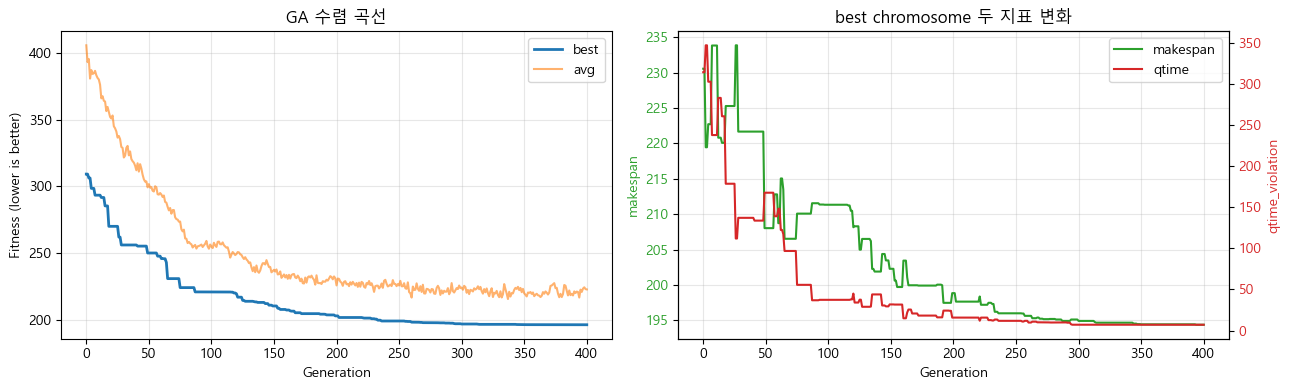

In [6]:
df_history = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) Fitness 수렴 곡선
axes[0].plot(df_history['gen'], df_history['best_fitness'], label='best', color='C0', linewidth=2)
axes[0].plot(df_history['gen'], df_history['avg_fitness'], label='avg', color='C1', alpha=0.6)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Fitness (lower is better)')
axes[0].set_title('GA 수렴 곡선')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) Best chromosome 두 지표 변화
ax2 = axes[1]
l1 = ax2.plot(df_history['gen'], df_history['best_makespan'], label='makespan', color='C2')
ax2.set_xlabel('Generation')
ax2.set_ylabel('makespan', color='C2')
ax2.tick_params(axis='y', labelcolor='C2')

ax2_t = ax2.twinx()
l2 = ax2_t.plot(df_history['gen'], df_history['best_qtime'], label='qtime', color='C3')
ax2_t.set_ylabel('qtime_violation', color='C3')
ax2_t.tick_params(axis='y', labelcolor='C3')

ax2.set_title('best chromosome 두 지표 변화')
ax2.grid(alpha=0.3)

lines = l1 + l2
ax2.legend(lines, [l.get_label() for l in lines], loc='upper right')

plt.tight_layout()
plt.show()

## 최종 best chromosome 정보

In [7]:
sim_input_best = decode(best, encoded)

print('─── best chromosome fitness ───')
print(f'  makespan: {best.fitness[0]:.2f}')
print(f'  qtime:    {best.fitness[1]:.2f}')
print()
print('─── 디코딩 결과 (시뮬 실제 입력) ───')
print(f'  job 투입 순서: {sim_input_best.job_priority}')
print()
print(f'  pm_thresholds: {sim_input_best.pm_thresholds}')
print()
print('  op별 머신 할당 (앞 10개):')
for op, m in list(sim_input_best.op_machine.items())[:10]:
    print(f'    {op} → {m}')

─── best chromosome fitness ───
  makespan: 194.38
  qtime:    7.05

─── 디코딩 결과 (시뮬 실제 입력) ───
  job 투입 순서: ['J44', 'J57', 'J56', 'J10', 'J34', 'J30', 'J1', 'J20', 'J43', 'J4', 'J21', 'J46', 'J18', 'J25', 'J42', 'J47', 'J26', 'J16', 'J33', 'J12', 'J13', 'J3', 'J23', 'J6', 'J27', 'J49', 'J45', 'J37', 'J52', 'J28', 'J60', 'J8', 'J50', 'J15', 'J32', 'J58', 'J2', 'J40', 'J9', 'J55', 'J39', 'J14', 'J5', 'J7', 'J24', 'J35', 'J53', 'J22', 'J38', 'J41', 'J11', 'J48', 'J19', 'J59', 'J29', 'J54', 'J31', 'J36', 'J17', 'J51']

  pm_thresholds: {'M1': 0.07, 'M2': 0.05, 'M3': 0.05, 'M4': 0.07, 'M5': 0.01, 'M6': 0.09, 'M7': 0.03, 'M8': 0.07, 'M9': 0.1, 'M10': 0.1, 'M11': 0.2, 'M12': 0.07, 'M13': 0.09, 'M14': 0.01, 'M15': 0.01, 'M16': 0.03, 'M17': 0.03, 'M18': 0.2, 'M19': 0.01, 'M20': 0.03, 'M21': 0.05, 'M22': 0.09, 'M23': 0.07, 'M24': 0.2, 'M25': 0.01, 'M26': 0.05, 'M27': 0.05, 'M28': 0.07, 'M29': 0.07, 'M30': 0.05, 'M31': 0.01, 'M32': 0.01, 'M33': 0.09, 'M34': 0.03, 'M35': 0.01, 'M36': 0.07, 'M37': 

## Best chromosome 시뮬레이션 + 간트 차트

GA가 찾아낸 best chromosome으로 시뮬레이션을 한 번 더 돌려 간트 차트 시각화.

In [8]:
# best chromosome으로 시뮬레이션 재실행 (시드 고정 → fitness와 동일 결과)
random.seed(ga.evaluator.seed)

env = simpy.Environment()
event_logger = EventLogger(env)
scheduler = Scheduler(
    env=env,
    data=data,
    event_logger=event_logger,
    pm_hazard_threshold=0.0,
    job_priority=sim_input_best.job_priority,
    op_machine=sim_input_best.op_machine,
    pm_thresholds=sim_input_best.pm_thresholds,
)
env.run(until=scheduler.job_chk_process)

fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f'GA Best Chromosome 간트 차트 (Simulation Time: {round(env.now / 60, 3)} h)'
)
fig.show()

## 초기 vs 최종 비교

In [9]:
init = history[0]
final = history[-1]

print('─── 초기 (gen 0, 무작위) ───')
print(f"  best fitness: {init['best_fitness']:.2f}")
print(f"    makespan:   {init['best_makespan']:.2f}")
print(f"    qtime:      {init['best_qtime']:.2f}")
print(f"  avg  fitness: {init['avg_fitness']:.2f}")
print()
print('─── 최종 (GA 진화 후) ───')
print(f"  best fitness: {final['best_fitness']:.2f}")
print(f"    makespan:   {final['best_makespan']:.2f}")
print(f"    qtime:      {final['best_qtime']:.2f}")
print(f"  avg  fitness: {final['avg_fitness']:.2f}")
print()

def pct_change(initial, final_val):
    """초기값이 0이면 절대 변화량 표시, 아니면 변화율(%) 표시."""
    if initial == 0:
        return f'{initial:.2f} → {final_val:.2f} (초기값 0이라 변화율 미정의)'
    return f'{(final_val - initial) / initial * 100:+.1f}%'

print(f'best fitness 개선율: {pct_change(init["best_fitness"], final["best_fitness"])}')
print(f'makespan 변화율:     {pct_change(init["best_makespan"], final["best_makespan"])}')
print(f'qtime 변화율:        {pct_change(init["best_qtime"], final["best_qtime"])}')

─── 초기 (gen 0, 무작위) ───
  best fitness: 309.09
    makespan:   230.56
    qtime:      314.10
  avg  fitness: 405.63

─── 최종 (GA 진화 후) ───
  best fitness: 196.14
    makespan:   194.38
    qtime:      7.05
  avg  fitness: 222.62

best fitness 개선율: -36.5%
makespan 변화율:     -15.7%
qtime 변화율:        -97.8%


## 결과 저장

세대별 history는 CSV로, best chromosome 간트 차트는 HTML로 같은 폴더에 저장. 번호는 자동 증가.

In [10]:
SAVE_DIR = 'ga결과/'   # 결과 저장 폴더
os.makedirs(SAVE_DIR, exist_ok=True)


def next_filepath(prefix: str, suffix: str) -> str:
    """SAVE_DIR 안에서 {prefix}NNN{suffix} 패턴의 가장 큰 번호 + 1로 새 경로 반환."""
    existing_nums = [
        int(f[len(prefix):-len(suffix)])
        for f in os.listdir(SAVE_DIR)
        if f.startswith(prefix) and f.endswith(suffix)
        and f[len(prefix):-len(suffix)].isdigit()
    ]
    next_num = max(existing_nums, default=0) + 1
    return os.path.join(SAVE_DIR, f'{prefix}{next_num:03d}{suffix}')


# ─── CSV 저장 (세대별 history + GA 파라미터는 첫 행에만) ───
params = {
    'pm_levels':           str(PM_LEVELS),
    'pop_size':            POP_SIZE,
    'n_generations':       N_GENERATIONS,
    'crossover_rate':      CROSSOVER_RATE,
    'mut_job':             MUT_JOB,
    'mut_machine':         MUT_MACHINE,
    'mut_pm':              MUT_PM,
    'tournament_k':        TOURNAMENT_K,
    'n_elites':            N_ELITES,
    'alpha':               ALPHA,
    'stagnation_patience': STAGNATION_PATIENCE,
    'mutation_boost':      MUTATION_BOOST,
    'immigrant_ratio':     IMMIGRANT_RATIO,
    'boost_duration':      BOOST_DURATION,
    'boost_cooldown':      BOOST_COOLDOWN,
    'seed':                SEED,
}
df_out = df_history.copy()
for k, v in params.items():
    df_out[k] = ''
    df_out.at[0, k] = v

csv_path = next_filepath('result_ga_history_', '.csv')
df_out.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'saved: {csv_path}')

# ─── HTML 저장 (best 간트 차트) ───
html_path = next_filepath('result_ga_gantt_', '.html')
fig.write_html(html_path)
print(f'saved: {html_path}')

saved: ga결과/result_ga_history_017.csv
saved: ga결과/result_ga_gantt_017.html
